In [1]:
from google.colab import files
uploaded = files.upload()

Saving final_preprocessed_dataset (1).csv to final_preprocessed_dataset (1).csv


In [4]:
import pandas as pd

df = pd.read_csv("final_preprocessed_dataset (1).csv")
df

,clean_text,category,urgency
0,anniversary special buy one get one free loyal...,promotions,low
1,amazon used new device refund processed claim ...,spam,low
2,google inquiry hi following google application...,spam,low
3,digital ritual experience creation crosscultur...,social_media,low
4,post moved programming help trending cooking c...,forum,low
...,...,...,...
10029,free upgrade purchase deal end time item lowes...,promotions,low
10030,authentication code use verify new device logi...,verify_code,low
10031,live tech conference keynote friend checked do...,social_media,low
10032,news group follow alex anyone free weekend lis...,social_media,low


In [5]:
X = df['clean_text']
y = df['category']

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 8027
Test size: 2007


In [12]:
print("Total dataset size:", len(df))
print("Train size:", len(X_train))
print("Test size:", len(X_test))

print("\nTrain Percentage:", (len(X_train)/len(df))*100)
print("Test Percentage:", (len(X_test)/len(df))*100)


Total dataset size: 10034
Train size: 8027
Test size: 2007

Train Percentage: 79.99800677695833
Test Percentage: 20.00199322304166


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
print("Train TF-IDF Shape:", X_train_tfidf.shape)
print("Test TF-IDF Shape:", X_test_tfidf.shape)

Train TF-IDF Shape: (8027, 4534)
Test TF-IDF Shape: (2007, 4534)


In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=200)
model.fit(X_train_tfidf, y_train)


LogisticRegression(max_iter=200)

In [10]:
y_pred = model.predict(X_test_tfidf)
print("predict value:",y_pred)
print("test value:",y_test)

predict value: ['updates' 'promotions' 'verify_code' ... 'verify_code' 'social_media'
 'updates']
test value: 3761         updates
590       promotions
5130     verify_code
9858         updates
3989         updates
            ...     
3077    social_media
2039           forum
8068     verify_code
5853    social_media
6689         updates
Name: category, Length: 2007, dtype: object


In [11]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9765819631290483

Classification Report:

              precision    recall  f1-score   support

       forum       0.98      0.96      0.97       372
  promotions       0.99      0.97      0.98       279
social_media       0.98      0.98      0.98       429
        spam       0.97      0.98      0.98       367
     updates       0.96      0.98      0.97       330
 verify_code       0.98      0.99      0.99       230

    accuracy                           0.98      2007
   macro avg       0.98      0.98      0.98      2007
weighted avg       0.98      0.98      0.98      2007



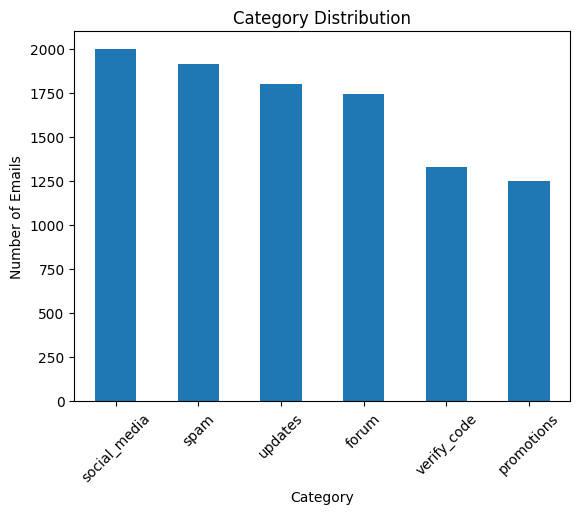

In [13]:
#Category Distribution Graph
import matplotlib.pyplot as plt

category_counts = df['category'].value_counts()

plt.figure()
category_counts.plot(kind='bar')
plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Emails")
plt.xticks(rotation=45)
plt.show()

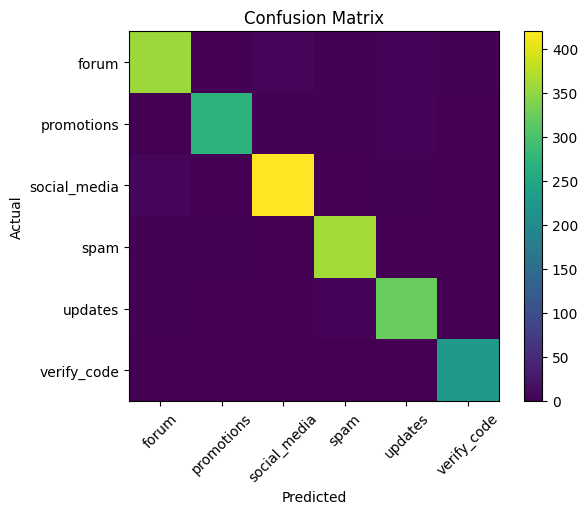

In [14]:
#Confusion Matrix Graph
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

labels = np.unique(y_test)
plt.xticks(range(len(labels)), labels, rotation=45)
plt.yticks(range(len(labels)), labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

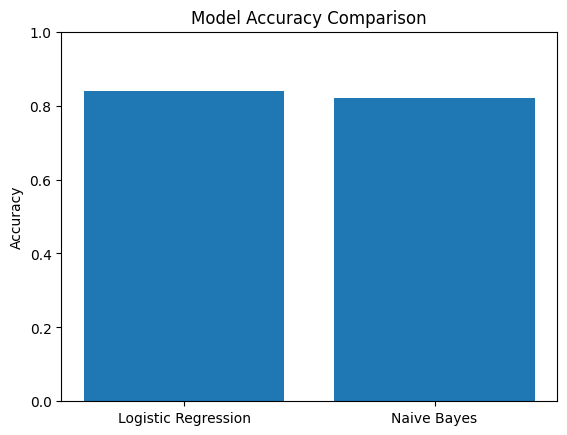

In [20]:
#Accuracy Graph
models = ['Logistic Regression', 'Naive Bayes']
accuracies = [0.84, 0.82]  # replace with your actual accuracy

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()